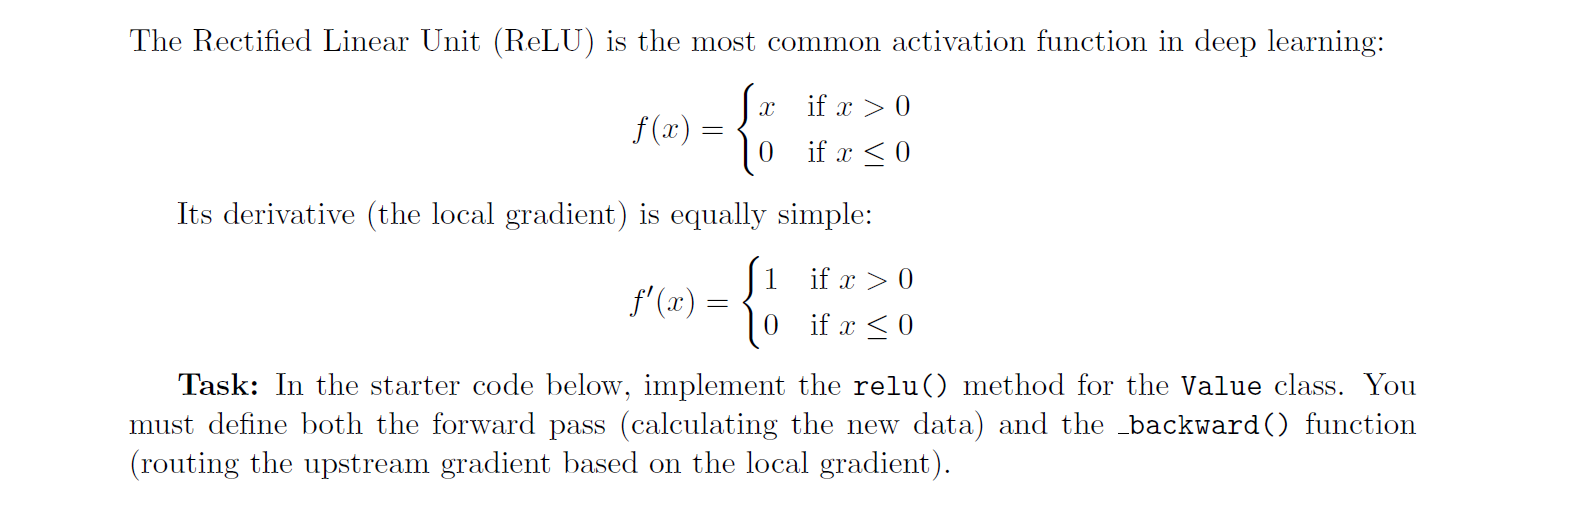

In [1]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def relu(self):
        # Forward pass for ReLU
        out_data = self.data if self.data > 0 else 0.0
        out = Value(out_data, (self,), 'ReLU')

        def _backward():
            # Local gradient of ReLU:
            # 1 if input > 0, otherwise 0
            self.grad += (1.0 if out.data > 0 else 0.0) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        # Build topological order of the graph
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # Backpropagation
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [2]:
x = Value(3.0)
y = x.relu()
y.backward()

print("x.data =", x.data)
print("y.data =", y.data)
print("x.grad =", x.grad)

x.data = 3.0
y.data = 3.0
x.grad = 1.0
